#                                                           COVID-19 Patient Data Analysis

## Exploratory Data Analysis (EDA)

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Load Dataset

In [2]:
df =pd.read_csv("corana_19 patient dataset.csv")

### display the first five rows of the dataset

In [3]:
df.head()

,Date,Country,Cases,Deaths,Recovered,Active,Vaccine,Risk
0,2020-04-12,India,388449,7904,188490.0,192055,59.81,Yes
1,2021-03-11,Italy,14253,11106,3147.0,0,5.16,Yes
2,2020-09-27,Brazil,76425,13081,3471.0,59873,71.12,Yes
3,2020-04-16,France,240873,3591,237282.0,0,30.17,Yes
4,2020-03-12,Italy,406315,10339,120312.0,275664,NaN,Yes


### display the last five rows of the dataset

In [4]:
df.tail()

,Date,Country,Cases,Deaths,Recovered,Active,Vaccine,Risk
1095,2020-10-18,Italy,179536,8590,170946.0,0,2.86,Yes
1096,2020-10-09,Russia,492149,1733,405453.0,84963,91.34,Yes
1097,2020-03-09,UK,388747,13870,146721.0,228156,63.45,Yes
1098,2021-10-21,Brazil,260216,2125,168785.0,89306,88.65,Yes
1099,2020-01-11,Italy,347122,2171,204535.0,140416,25.22,Yes


### How many rows and columns are present in the dataset

In [5]:
df.shape

(1100, 8)

### What are the column names in the dataset?

In [6]:
df.columns

Index(['Date', 'Country', 'Cases', 'Deaths', 'Recovered', 'Active', 'Vaccine',
       'Risk'],
      dtype='object')

### What are the data types of the columns?

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1100 non-null   object 
 1   Country    1092 non-null   object 
 2   Cases      1100 non-null   int64  
 3   Deaths     1100 non-null   int64  
 4   Recovered  1092 non-null   float64
 5   Active     1100 non-null   int64  
 6   Vaccine    1092 non-null   float64
 7   Risk       1100 non-null   object 
dtypes: float64(2), int64(3), object(3)
memory usage: 68.9+ KB


In [8]:
### What is the statistical summary of the dataset?

df.describe()

,Cases,Deaths,Recovered,Active,Vaccine
count,1100.000000,1100.000000,1092.000000,1100.000000,1092.000000
mean,252181.690909,7630.586364,153084.109890,91490.055455,47.004716
std,143329.232851,4292.079479,108175.956496,117087.350526,27.438645
min,226.000000,1.000000,0.000000,0.000000,0.000000
25%,132166.250000,3979.000000,63068.000000,0.000000,23.262500
50%,253343.000000,7625.500000,137774.000000,26815.500000,47.025000
75%,378526.250000,11224.250000,225359.750000,166076.750000,71.027500
max,499983.000000,14996.000000,448614.000000,468689.000000,94.960000


### Are there any missing values in the dataset?

In [9]:
df.isnull().sum()

Date         0
Country      8
Cases        0
Deaths       0
Recovered    8
Active       0
Vaccine      8
Risk         0
dtype: int64

In [10]:
df["Recovered"].fillna(df["Recovered"].median(), inplace=True)
df["Vaccine"].fillna(df["Vaccine"].median(), inplace=True)
df["Country"].fillna(df["Country"].mode()[0], inplace=True)


In [11]:
df.isnull().sum()

Date         0
Country      0
Cases        0
Deaths       0
Recovered    0
Active       0
Vaccine      0
Risk         0
dtype: int64

### Are there any duplicate records?

In [12]:
df.duplicated().sum()

np.int64(0)

### Distribution of Numerical colomns and Categorical colomns.

In [13]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
numerical_cols 

Index(['Cases', 'Deaths', 'Recovered', 'Active', 'Vaccine'], dtype='object')

In [14]:
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols

Index(['Date', 'Country', 'Risk'], dtype='object')

### Are there any outliers in numerical columns?

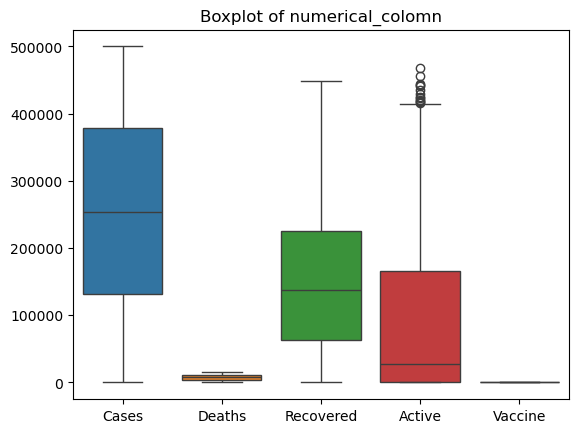

In [15]:
sns.boxplot(data=df[numerical_cols])
plt.title("Boxplot of numerical_colomn")
plt.show()

### insights:-
- The boxplot of numerical columns is found the outliers.

In [16]:
Q1 = df["Active"].quantile(0.25)
Q3 = df["Active"].quantile(0.75)

IQR = Q3 - Q1


upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper Limit:", upper_limit)


df["Active"] = np.where(df["Active"] >upper_limit,upper_limit,df["Active"])

Q1: 0.0
Q3: 166076.75
IQR: 166076.75
Upper Limit: 415191.875


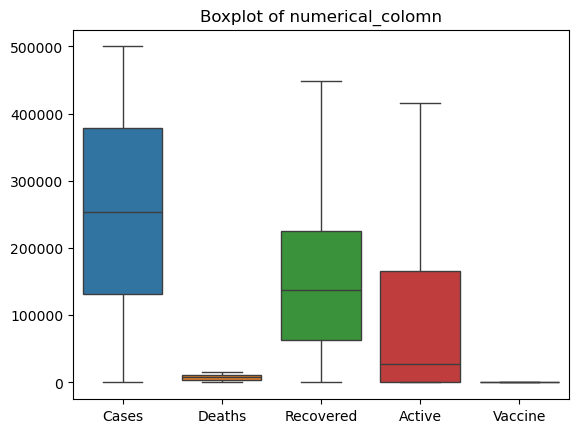

In [17]:
sns.boxplot(data=df[numerical_cols])
plt.title("Boxplot of numerical_colomn")
plt.show()

### Insights:-
- the boxplot of numerical columns are remove outlieres.

## UNIVARIANT

### 1.Visualization:-
- distribution of Cases

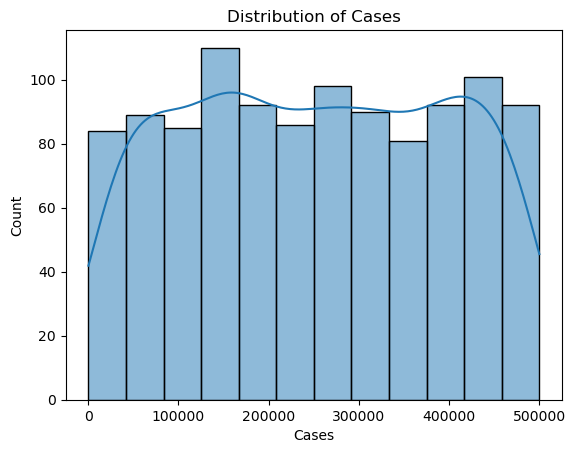

In [18]:
sns.histplot(df['Cases'], kde=True)
plt.title('Distribution of Cases')
plt.show()


### Insights:-
- The distribution shows how COVID-19 cases are spread across the dataset.

###  2.Visualization:-
- distribution of Cases Deaths

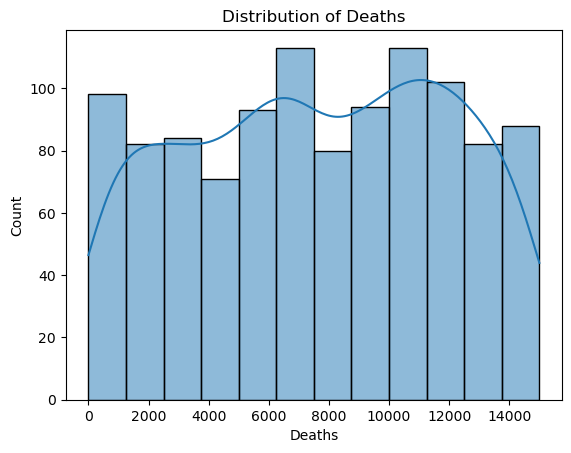

In [19]:
sns.histplot(df['Deaths'], kde=True)
plt.title('Distribution of Deaths')
plt.show()

### Insights:-
- The distribution shows the variation in the number of COVID-19 deaths.

###  3.Visualization:-
- distribution of Recovered Cases 

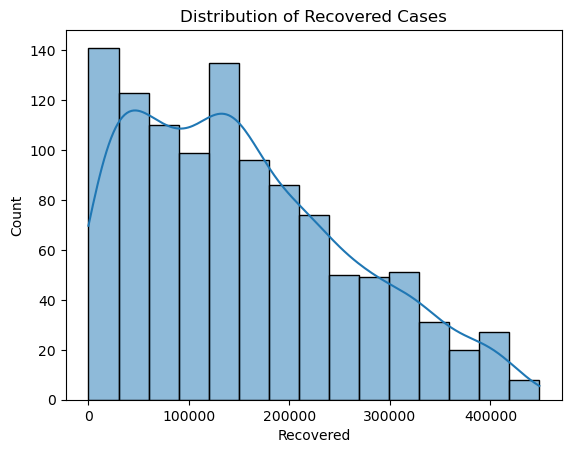

In [20]:
sns.histplot(df['Recovered'], kde=True)
plt.title('Distribution of Recovered Cases')
plt.show()

### Insights:-
- The distribution shows the variation in recovered COVID-19 cases.

###  4.Visualization:-
- distribution of Active cases 

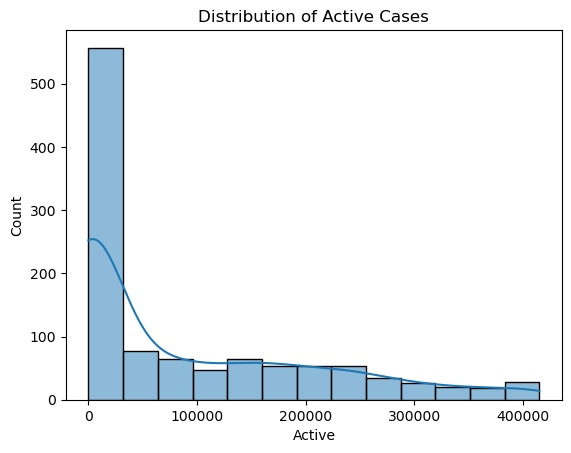

In [21]:
sns.histplot(df['Active'], kde=True)
plt.title('Distribution of Active Cases')
plt.show()

### Insights:-
- The distribution shows how active COVID-19 cases vary across the dataset

###  5.Visualization:-
- distribution of across countries. 

In [22]:
df["Country"].nunique()

10

## Insights:-
- Their are 10 countries data in column.

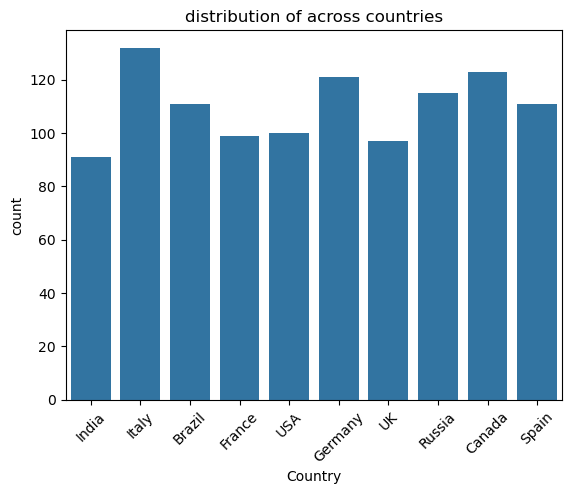

In [23]:
sns.countplot(x='Country', data=df)
plt.xticks(rotation=45)
plt.title("distribution of across countries")
plt.show()

### Insights:-
-The chart shows the number of records available for each country.

###  6.Visualization:-
- distribution of Risk levels

In [24]:
df["Risk"].unique()

array(['Yes', 'No'], dtype=object)

## Insights:-
- this columns are two unique value first is YES and second is NO

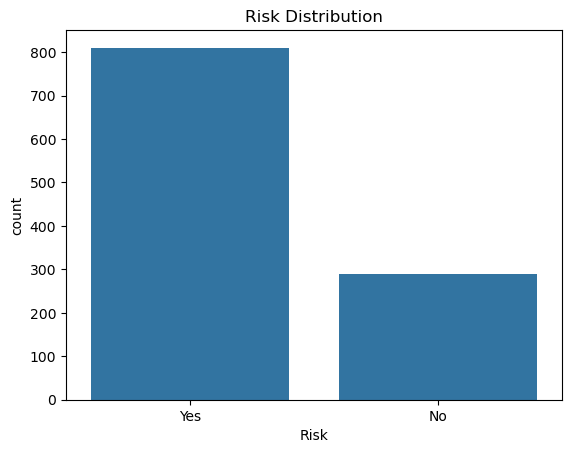

In [25]:
sns.countplot(x='Risk', data=df)
plt.title('Risk Distribution')
plt.show()

## Insights:-
- The chart shows the distribution of different COVID-19 risk levels.

# BIVARIANT

###  1.Visualization:-
- The relationship between Cases and Deaths

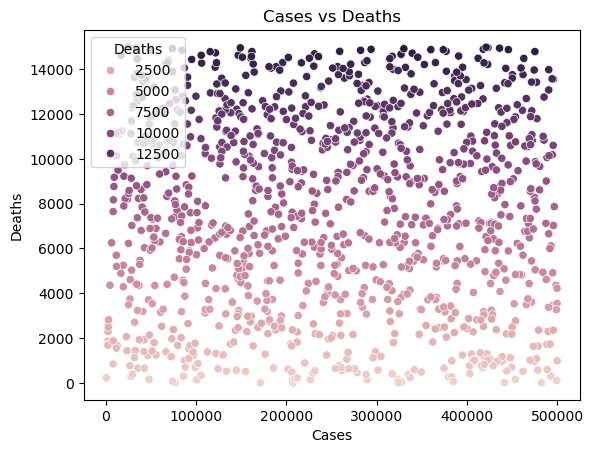

In [26]:
sns.scatterplot(x='Cases', y='Deaths',hue="Deaths", data=df)
plt.title('Cases vs Deaths')
plt.show()

## Insights:-
- The scatter plot helps identify the relationship between COVID-19 cases and deaths.

###  2.Visualization:-
- The relationship between Cases and Active cases.

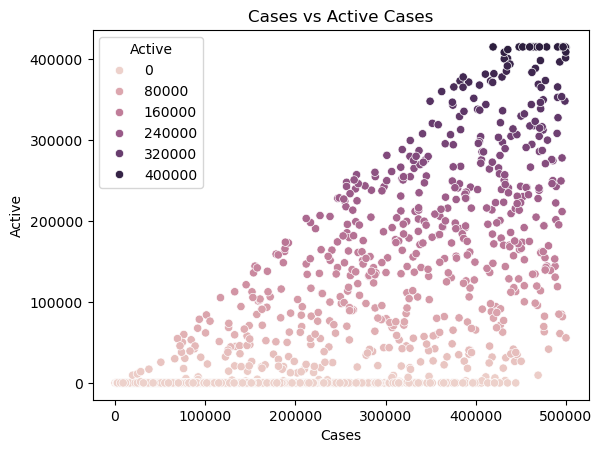

In [27]:
sns.scatterplot(x='Cases', y='Active',hue="Active", data=df)
plt.title('Cases vs Active Cases')
plt.show()

## Insights:-
- The plot shows how active cases vary with total COVID-19 case

###  3.Visualization:-
- The Active case VS countries

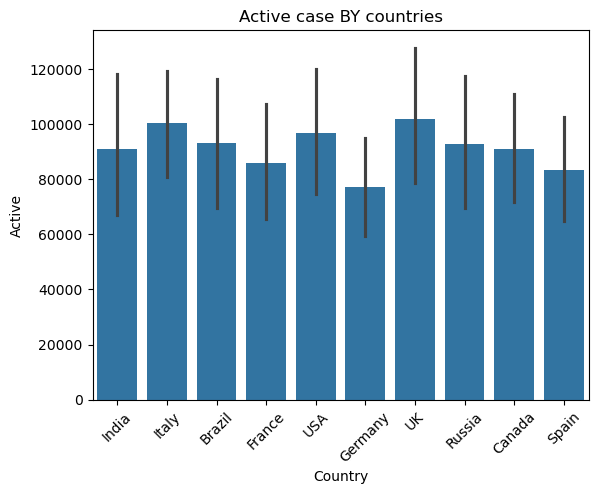

In [28]:
sns.barplot(x='Country', y='Active' ,data=df)
plt.xticks(rotation=45)
plt.title("Active case BY countries")
plt.show()

## Insights:-
- The bar plot compares the distribution of active cases across countries.

###  4.Visualization:-
- The relationship between Risk and Active cases.
  

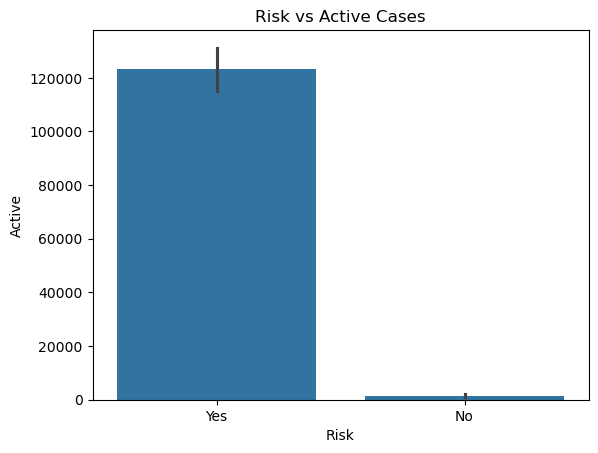

In [29]:
sns.barplot(x='Risk', y='Active', data=df)
plt.title('Risk vs Active Cases')
plt.show()

## Insights:-
- Active cases can be compared across different risk categorie

# MULTIVAIRANT

###  1.Visualization:-
- The Cases, Deaths and Risk relation.

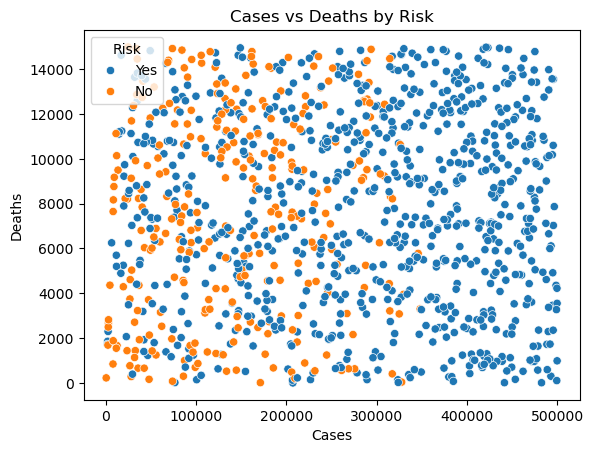

In [30]:
sns.scatterplot( x='Cases', y='Deaths',
hue='Risk', data=df)
plt.title('Cases vs Deaths by Risk')
plt.show()

## Insights:-
- The visualization compares the relationship between cases and deaths across different risk levels.

###  2.Visualization:-
- The correlation between numerical columns.

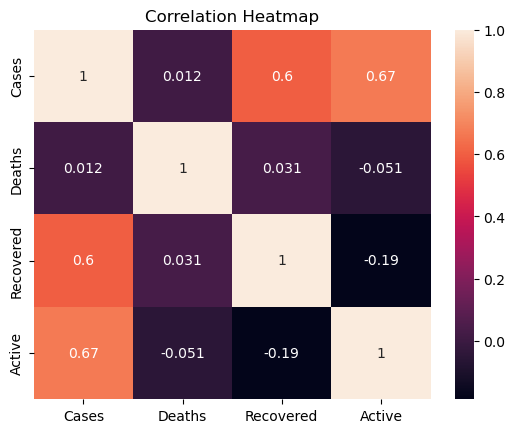

In [31]:
corr = df[['Cases', 'Deaths', 'Recovered', 'Active']].corr()
sns.heatmap(corr, annot=True)
plt.title('Correlation Heatmap')
plt.show()

## Insights:-
- The correlation heatmap shows the strength and direction of relationships between numerical Columns.

### SAVE THE CLEANED DATASET 

In [32]:
df.to_csv("Covid_19_Cleaned.csv",index=False)